In [1]:
# Import all necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_moons
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report


In [9]:
# Generate 2D non-linear classification data using make_moons
X, y = make_moons(n_samples=300, noise=0.25, random_state=42)
X

array([[ 8.64395519e-01, -2.64509343e-01],
       [ 2.45115375e+00, -1.17549859e-01],
       [-3.50712335e-01,  4.49211054e-01],
       [ 7.41295508e-01,  4.32918827e-01],
       [ 1.18875554e+00, -5.18301281e-01],
       [ 1.00058840e+00, -3.14414711e-01],
       [ 3.21492251e-01, -1.30559756e-01],
       [-4.03548900e-01,  6.61359843e-01],
       [ 7.62936531e-01, -2.30139250e-02],
       [ 3.13264293e-01,  2.00795238e-02],
       [ 1.41803455e+00, -2.47352113e-02],
       [ 4.18401771e-01,  7.30461845e-01],
       [ 1.12773515e+00, -4.77783214e-01],
       [ 8.00767998e-01,  1.07926837e+00],
       [-2.06436217e-02,  2.20834590e-01],
       [ 1.15255165e+00, -6.48254419e-01],
       [ 2.05396667e+00,  3.55015470e-01],
       [ 7.25170092e-01, -2.41784045e-01],
       [-6.40438648e-01,  2.29095455e-02],
       [ 3.82317477e-01,  4.36029090e-01],
       [-1.56547995e-02,  1.04132356e+00],
       [-1.01363665e+00,  3.13035015e-01],
       [ 1.53515683e+00, -5.83500301e-01],
       [ 1.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127769 (\N{CRESCENT MOON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


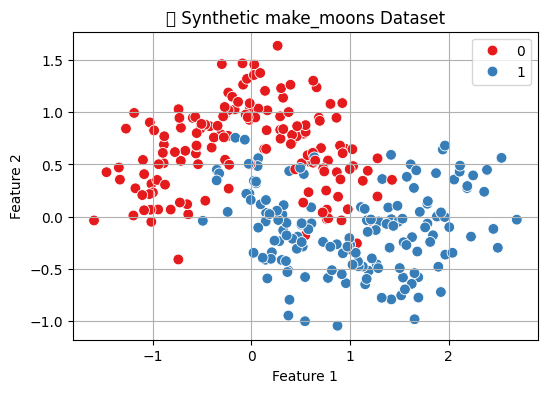

In [10]:
plt.figure(figsize=(6, 4))
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, palette='Set1', s=60)
plt.title("🌙 Synthetic make_moons Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)
plt.show()

Classification (finish): Lab

In [11]:
# === SETUP: load the provided file (regenerate it if missing) ===
import os
import numpy as np
import pandas as pd


def build_welds(csv_path="weld_inspection.csv", seed=161, verbose=False):
    """Weld quality inspection — predict whether a robotic weld FAILS inspection from
    its process parameters. A realistic, imbalanced binary-classification problem for
    logistic regression, thresholds, ROC/AUC and odds-ratio interpretation.

    Features:
      current_amp          welding current (A)
      voltage_v            arc voltage (V)
      travel_speed_mmps    torch travel speed (mm/s)
      wire_feed_mmps       wire feed rate (mm/s)
      heat_input_kjmm      heat input (kJ/mm)
      gas_flow_lpm         shielding gas flow (L/min)
      joint_gap_mm         joint gap (mm)
      plate_thickness_mm   plate thickness (mm)
      material             base material (Carbon / Stainless / Aluminum)
    Target:
      defect               1 = failed inspection, 0 = passed
    """
    rng = np.random.default_rng(seed)
    N = 2600
    current = rng.normal(190, 30, N).clip(90, 300)
    voltage = (18 + 0.03 * current + rng.normal(0, 1.2, N)).clip(14, 32)
    travel = rng.normal(8, 2.2, N).clip(3, 16)
    wire = (current * 0.03 + rng.normal(0, 0.6, N)).clip(2, 12)
    heat = (voltage * current / (travel * 1000)).clip(0.2, 4.0)     # kJ/mm
    gas = rng.normal(16, 3, N).clip(6, 28)
    gap = rng.gamma(2.0, 0.35, N).clip(0, 4).round(2)               # right-skewed
    thick = rng.choice([3, 5, 6, 8, 10, 12, 16], N).astype(float)
    material = rng.choice(["Carbon", "Stainless", "Aluminum"], N, p=[0.55, 0.30, 0.15])
    mat_risk = np.select([material == "Carbon", material == "Stainless", material == "Aluminum"],
                         [0.0, 0.3, 0.8])                            # Aluminum harder to weld

    # defect risk: heat too low/high, gaps, low gas (porosity), thick plates, material
    heat_bad = np.abs(heat - 1.3)
    z = (-3.2
         + 1.6 * heat_bad
         + 1.1 * gap
         + 0.05 * (16 - gas)
         + 0.04 * (thick - 8)
         + 0.012 * (travel - 8) ** 2
         + mat_risk)
    p = 1 / (1 + np.exp(-z))
    defect = (rng.random(N) < p).astype(int)

    df = pd.DataFrame({
        "current_amp": current.round(1), "voltage_v": voltage.round(2),
        "travel_speed_mmps": travel.round(2), "wire_feed_mmps": wire.round(2),
        "heat_input_kjmm": heat.round(3), "gas_flow_lpm": gas.round(1),
        "joint_gap_mm": gap, "plate_thickness_mm": thick,
        "material": material, "defect": defect,
    })
    df.to_csv(csv_path, index=False)
    if verbose:
        print("welds:", df.shape)
        print("defect rate:", round(df.defect.mean(), 3))
        print("defect by material:\n",
              df.groupby("material")["defect"].mean().round(3).to_string())
    return df

if not os.path.exists('weld_inspection.csv'):
    build_welds(); print('Generated dataset file.')
else:
    print('Found the provided dataset file.')

Generated dataset file.


In [12]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid')
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
df = pd.read_csv('weld_inspection.csv')
y = df['defect']; X = df.drop(columns='defect')
num = X.select_dtypes('number').columns.tolist(); cat = ['material']
pre = ColumnTransformer([('num', StandardScaler(), num),
                         ('cat', OneHotEncoder(drop='first'), cat)])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)
print('shape:', df.shape, '| defect rate:', round(y.mean(), 3))
df.head(3)

shape: (2600, 10) | defect rate: 0.281


,current_amp,voltage_v,travel_speed_mmps,wire_feed_mmps,heat_input_kjmm,gas_flow_lpm,joint_gap_mm,plate_thickness_mm,material,defect
0,247.7,23.37,7.78,7.57,0.744,16.0,0.79,8.0,Carbon,0
1,227.3,22.98,8.90,5.96,0.587,16.5,0.66,12.0,Carbon,0
2,230.6,24.46,8.15,7.76,0.692,12.0,0.81,10.0,Stainless,0


In [13]:

# -----------------------------------------------------------
# 🔹 1A. A SINGLE DECISION TREE
# -----------------------------------------------------------
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score
tree = Pipeline([('prep', pre), ('clf', DecisionTreeClassifier(max_depth=4, random_state=0))])
tree.fit(X_train, y_train)
print('test F1 (depth 4):', round(f1_score(y_test, tree.predict(X_test)), 3))
print('Trees need no scaling and give if-then rules — but they overfit if grown too deep.')

test F1 (depth 4): 0.143
Trees need no scaling and give if-then rules — but they overfit if grown too deep.


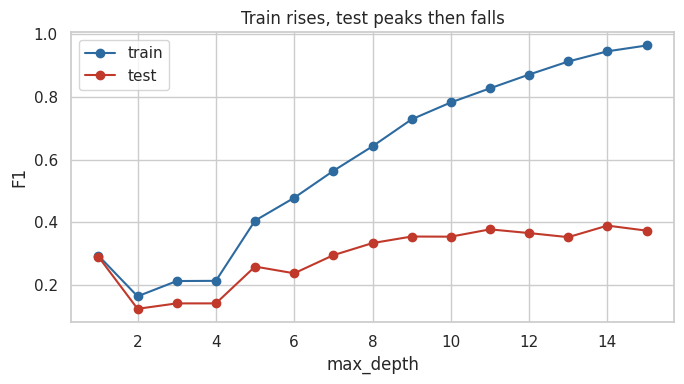

In [14]:

# -----------------------------------------------------------
# 🔹 1B. TRAIN vs TEST F1 ACROSS DEPTH (the overfitting curve)
# -----------------------------------------------------------
depths = range(1, 16); tr, te = [], []
for d in depths:
    m = Pipeline([('prep', pre), ('clf', DecisionTreeClassifier(max_depth=d, random_state=0))]).fit(X_train, y_train)
    tr.append(f1_score(y_train, m.predict(X_train)))
    te.append(f1_score(y_test, m.predict(X_test)))
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(depths), tr, 'o-', label='train', color='#2D6A9F')
ax.plot(list(depths), te, 'o-', label='test', color='#C0392B')
ax.set_xlabel('max_depth'); ax.set_ylabel('F1'); ax.set_title('Train rises, test peaks then falls')
ax.legend(); plt.tight_layout(); plt.show()

In [15]:
max_f1_idx = np.argmax(te)
best_depth = depths[max_f1_idx]

print(f'Best max_depth based on test F1: {best_depth}')
print(f'Highest test F1 score: {te[max_f1_idx]:.3f}')

# Refit the model with the best depth
best_tree = Pipeline([('prep', pre), ('clf', DecisionTreeClassifier(max_depth=best_depth, random_state=0))])
best_tree.fit(X_train, y_train)

print(f'Test F1 with best depth ({best_depth}): {f1_score(y_test, best_tree.predict(X_test)):.3f}')


Best max_depth based on test F1: 14
Highest test F1 score: 0.390
Test F1 with best depth (14): 0.390


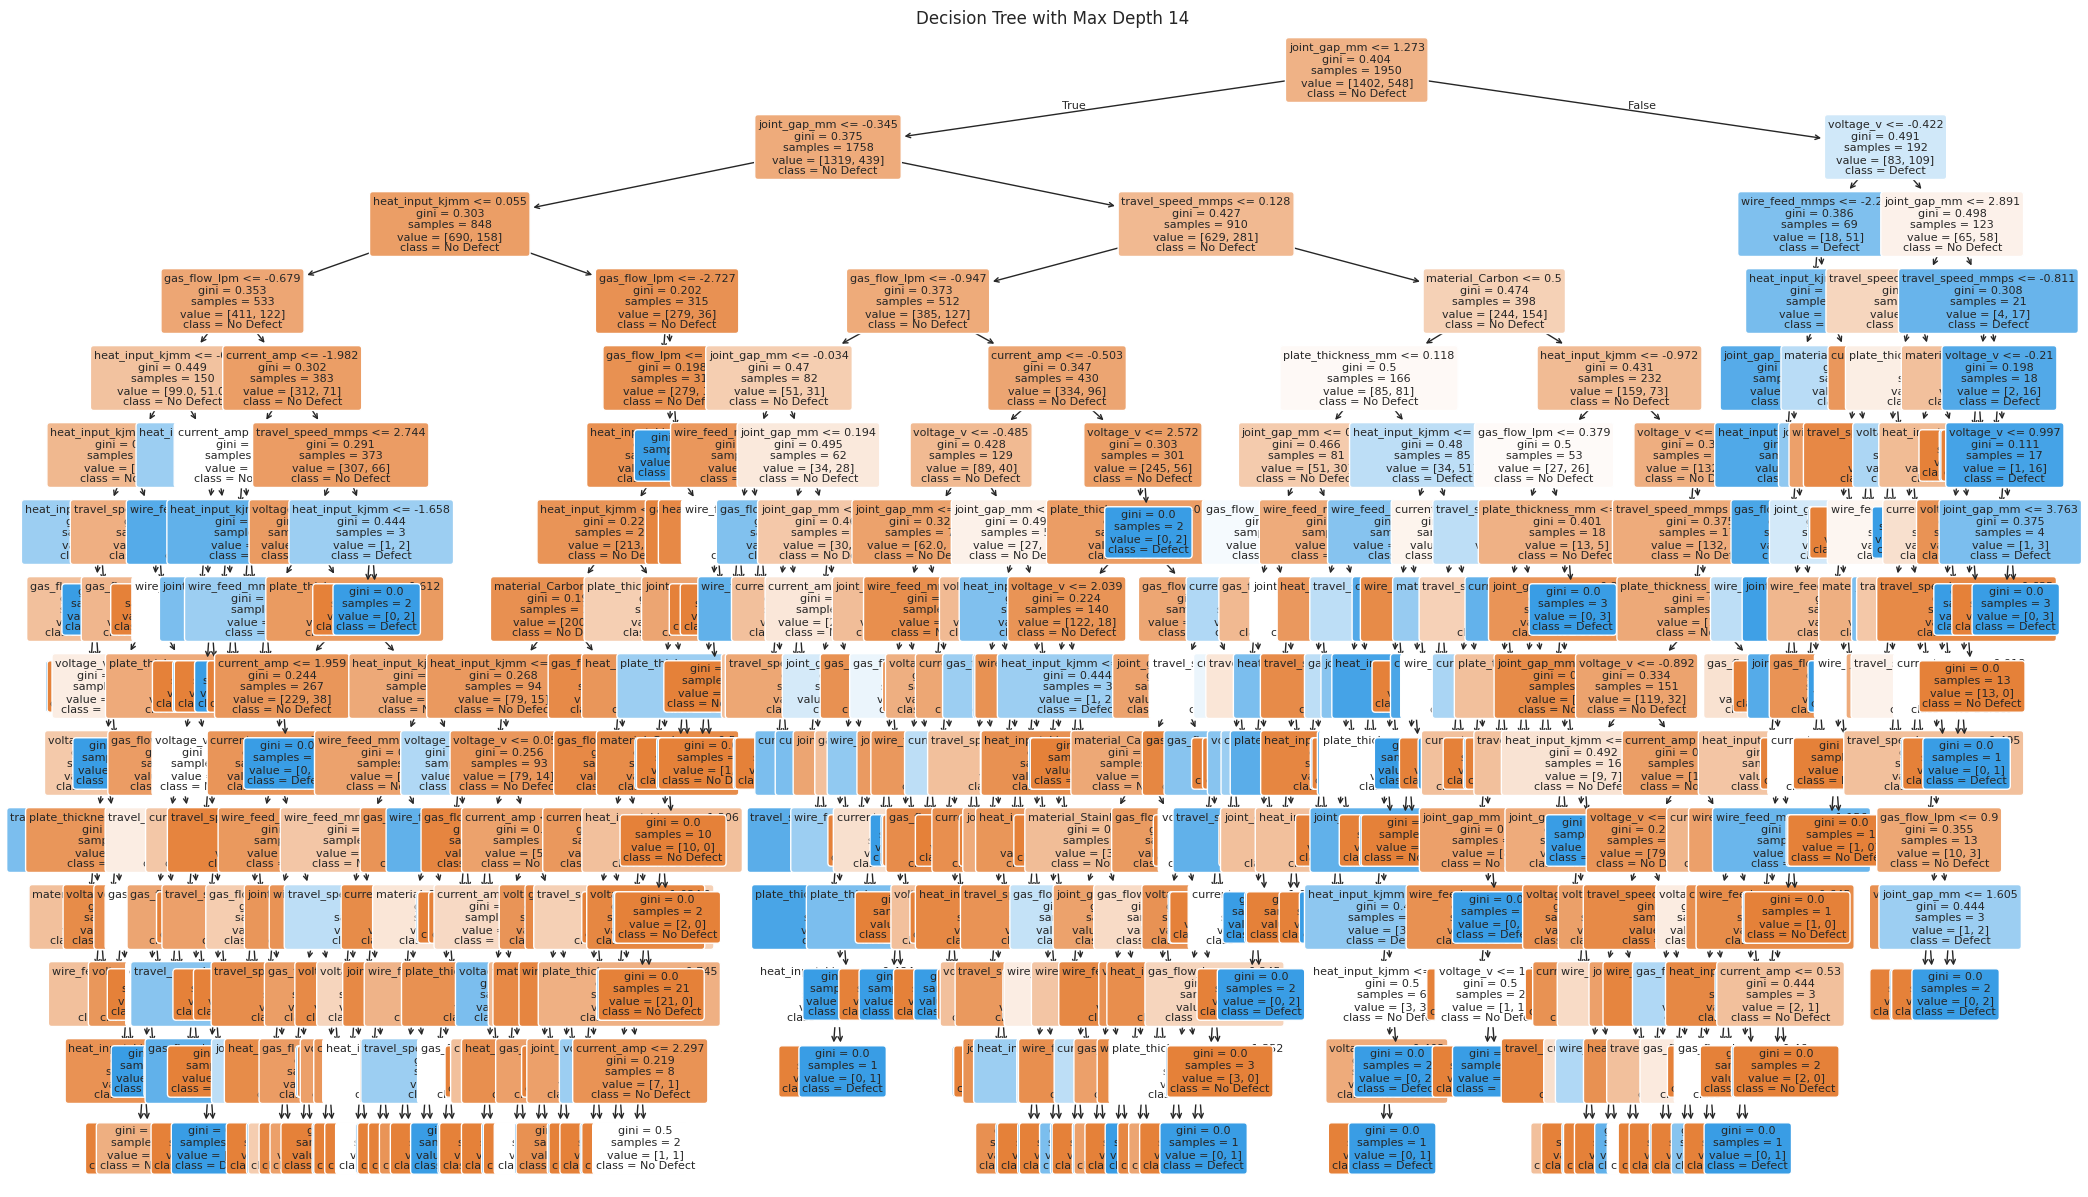

In [16]:
from sklearn.tree import plot_tree

# Extract the fitted DecisionTreeClassifier from the pipeline
dtc = best_tree.named_steps['clf']

# Get feature names after one-hot encoding
# The ColumnTransformer 'pre' has 'num' and 'cat' transformers
# 'num' (StandardScaler) preserves numerical feature names
# 'cat' (OneHotEncoder) creates new feature names for categorical features

# Get feature names for numerical features
feature_names = num.copy()

# Get feature names for one-hot encoded categorical features
onehot_features = pre.named_transformers_['cat'].get_feature_names_out(cat)
feature_names.extend(onehot_features)

# Plot the tree
plt.figure(figsize=(25, 15))
plot_tree(dtc,
          feature_names=feature_names,
          class_names=['No Defect', 'Defect'],
          filled=True,
          rounded=True,
          fontsize=8)
plt.title(f'Decision Tree with Max Depth {best_depth}')
plt.show()

In [17]:
# Get feature importances from the trained Decision Tree classifier
feature_importances = best_tree.named_steps['clf'].feature_importances_

# Create a DataFrame to display feature names and their importances
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

# Sort the DataFrame by importance in descending order
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("Feature Importances from the Best Decision Tree:")
display(importance_df)

Feature Importances from the Best Decision Tree:


,Feature,Importance
6,joint_gap_mm,0.184777
1,voltage_v,0.149376
0,current_amp,0.133381
5,gas_flow_lpm,0.121406
4,heat_input_kjmm,0.113326
2,travel_speed_mmps,0.108351
3,wire_feed_mmps,0.102725
7,plate_thickness_mm,0.053232
8,material_Carbon,0.017085
9,material_Stainless,0.016341


The widening gap between the train and test F1 scores at larger depths is a classic sign of overfitting. Here's what it means:

High Train F1 Score: As the max_depth of the decision tree increases, the model becomes more complex and gains the ability to learn very specific patterns and noise present in the training data. This allows it to fit the training data almost perfectly, leading to a high training F1 score.
Decreasing Test F1 Score: However, this extreme specialization on the training data makes the model less capable of generalizing to new, unseen data (the test set). It starts memorizing the training examples rather than learning the underlying general relationships. As a result, its performance on the test set degrades, and the test F1 score drops after reaching a peak.
In essence, the model is becoming too tailored to the quirks of the training data and loses its ability to make accurate predictions on data it hasn't seen before.



2. Ensembles — forests & boosting

In [19]:

# -----------------------------------------------------------
# 🔹 2A. RANDOM FOREST vs GRADIENT BOOSTING vs ONE TREE
# -----------------------------------------------------------
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import roc_auc_score
def evaluate(model):
    pipe = Pipeline([('prep', pre), ('clf', model)]).fit(X_train, y_train)
    pred = pipe.predict(X_test); proba = pipe.predict_proba(X_test)[:, 1]
    return f1_score(y_test, pred), roc_auc_score(y_test, proba)
for name, m in [('DecisionTree', DecisionTreeClassifier(max_depth=4, random_state=0)),
                ('RandomForest', RandomForestClassifier(n_estimators=300, random_state=0)),
                ('GradientBoosting', GradientBoostingClassifier(random_state=0))]:
    f1, auc = evaluate(m)
    print(f'{name:18s} F1: {f1:.3f} | ROC-AUC: {auc:.3f}')

DecisionTree       F1: 0.143 | ROC-AUC: 0.625
RandomForest       F1: 0.312 | ROC-AUC: 0.666
GradientBoosting   F1: 0.291 | ROC-AUC: 0.663


The core difference between Random Forest and Gradient Boosting lies in how they construct their ensemble of decision trees:

Random Forest (Bagging): Random Forest builds trees in parallel (independently) on random subsets of the training data (bootstrap samples). Each tree in the forest is trained on a different subset of data and features. The final prediction is made by averaging the predictions of all individual trees (for regression) or by majority voting (for classification). This parallel and independent training approach helps reduce variance and prevent overfitting.

Gradient Boosting (Boosting): Gradient Boosting builds trees sequentially. Each new tree is built to correct the errors (residuals) of the previous trees in the sequence. It focuses on the samples that were misclassified or poorly predicted by the earlier trees, gradually improving the model's performance. This sequential, error-correcting approach helps reduce bias.

Regarding the ROC-AUC scores from the previous execution:

RandomForest: ROC-AUC: 0.666
GradientBoosting: ROC-AUC: 0.663
Random Forest scored slightly higher on ROC-AUC in this instance.

3. Feature importance & explainability

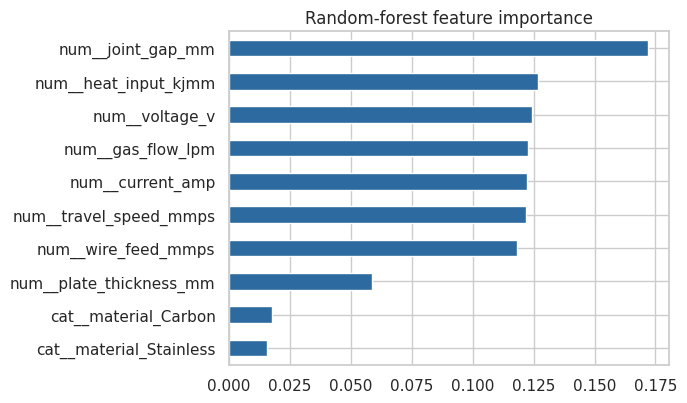

Top drivers:
num__joint_gap_mm       0.172
num__heat_input_kjmm    0.127
num__voltage_v          0.124
num__gas_flow_lpm       0.123


In [20]:

# -----------------------------------------------------------
# 🔹 3A. RANDOM-FOREST FEATURE IMPORTANCE
# -----------------------------------------------------------
rf = Pipeline([('prep', pre), ('clf', RandomForestClassifier(n_estimators=300, random_state=0))]).fit(X_train, y_train)
feat_names = rf.named_steps['prep'].get_feature_names_out()
imp = pd.Series(rf.named_steps['clf'].feature_importances_, index=feat_names).sort_values()
fig, ax = plt.subplots(figsize=(7, 4.2))
imp.plot(kind='barh', color='#2D6A9F', ax=ax); ax.set_title('Random-forest feature importance')
plt.tight_layout(); plt.show()
print('Top drivers:'); print(imp.sort_values(ascending=False).head(4).round(3).to_string())

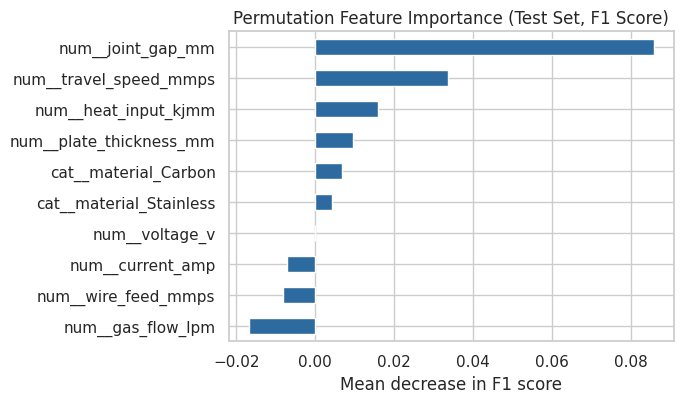

Permutation Feature Importance (Top drivers):
num__joint_gap_mm          0.086
num__travel_speed_mmps     0.034
num__heat_input_kjmm       0.016
num__plate_thickness_mm    0.010


In [22]:
from sklearn.inspection import permutation_importance

# Transform X_test using the fitted preprocessor
X_test_transformed = rf.named_steps['prep'].transform(X_test)

# Calculate permutation importance on the TRANSFORMED test set
# We use only the classifier (rf.named_steps['clf']) and the transformed data
result = permutation_importance(
    estimator=rf.named_steps['clf'], # Classifier only
    X=X_test_transformed,            # Transformed X_test
    y=y_test,
    n_repeats=10,
    random_state=42,
    scoring='f1',
    n_jobs=-1 # Use all available cores for faster computation
)

# Feature names should be those output by the preprocessor
# This aligns with the features that went into the classifier
feature_names_for_perm = rf.named_steps['prep'].get_feature_names_out()

# Create a Series for easy sorting and plotting
perm_imp = pd.Series(result.importances_mean, index=feature_names_for_perm).sort_values()

fig, ax = plt.subplots(figsize=(7, 4.2))
perm_imp.plot(kind='barh', color='#2D6A9F', ax=ax)
ax.set_title('Permutation Feature Importance (Test Set, F1 Score)')
ax.set_xlabel('Mean decrease in F1 score')
plt.tight_layout()
plt.show()

print('Permutation Feature Importance (Top drivers):')
print(perm_imp.sort_values(ascending=False).head(4).round(3).to_string())

In [24]:
# -----------------------------------------------------------
# 🔹 4A. GRID-SEARCH GRADIENT BOOSTING ON ROC-AUC
# -----------------------------------------------------------
from sklearn.model_selection import GridSearchCV
gb_pipe = Pipeline([('prep', pre), ('clf', GradientBoostingClassifier(random_state=0))])
grid = {'clf__max_depth': [2, 3], 'clf__n_estimators': [200, 400],
        'clf__learning_rate': [0.05, 0.1]}
gs = GridSearchCV(gb_pipe, grid, cv=4, scoring='roc_auc', n_jobs=-1).fit(X_train, y_train)
print('best params:', gs.best_params_)
print('best CV ROC-AUC:', round(gs.best_score_, 3))
best = gs.best_estimator_
print('tuned test ROC-AUC:', round(roc_auc_score(y_test, best.predict_proba(X_test)[:, 1]), 3))

best params: {'clf__learning_rate': 0.05, 'clf__max_depth': 2, 'clf__n_estimators': 400}
best CV ROC-AUC: 0.663
tuned test ROC-AUC: 0.665


### Why F1 or ROC-AUC over Accuracy for Imbalanced Problems?

For imbalanced classification problems (where one class significantly outnumbers the other, like in our `defect` prediction scenario), accuracy can be a misleading metric. Here's why F1-score and ROC-AUC are often preferred:

1.  **Accuracy's Pitfall:** If 90% of our data belongs to the 'no defect' class, a model that simply predicts 'no defect' for every single instance would achieve 90% accuracy. While numerically high, this model is completely useless for identifying actual defects, which is usually the primary goal in such scenarios. Accuracy doesn't distinguish between correctly classified majority and minority classes.

2.  **F1-Score:** The F1-score is the harmonic mean of precision and recall. It provides a better measure of a model's performance on the minority class:
    *   **Precision** measures the proportion of positive identifications that were actually correct (reducing false positives).
    *   **Recall** measures the proportion of actual positives that were identified correctly (reducing false negatives).
    
    For defect detection, we typically want a balance of not missing many defects (high recall) and not raising too many false alarms (high precision). A high F1-score indicates a good balance between these two, making it robust to class imbalance.

3.  **ROC-AUC (Receiver Operating Characteristic - Area Under the Curve):**
    *   The ROC curve plots the True Positive Rate (Recall) against the False Positive Rate at various threshold settings. It illustrates the trade-off between sensitivity and specificity.
    *   The AUC represents the degree or measure of separability between classes. It tells us how much the model is capable of distinguishing between the 'defect' and 'no defect' classes.
    
    A higher AUC indicates that the model is better at predicting 0s as 0s and 1s as 1s. Crucially, ROC-AUC is insensitive to class imbalance because it considers all possible classification thresholds and evaluates how well the model ranks positive instances higher than negative instances, regardless of the class distribution.

In [25]:
# -----------------------------------------------------------
# 🔹 5A. class_weight + THRESHOLD TUNING
# -----------------------------------------------------------
from sklearn.metrics import precision_score, recall_score
rf_bal = Pipeline([('prep', pre), ('clf', RandomForestClassifier(
    n_estimators=300, class_weight='balanced', random_state=0))]).fit(X_train, y_train)
proba = rf_bal.predict_proba(X_test)[:, 1]
for t in [0.3, 0.4, 0.5, 0.6]:
    pred = (proba >= t).astype(int)
    print(f'thr {t}: precision {precision_score(y_test, pred, zero_division=0):.3f} | recall {recall_score(y_test, pred):.3f} | F1 {f1_score(y_test, pred):.3f}')


thr 0.3: precision 0.398 | recall 0.557 | F1 0.465
thr 0.4: precision 0.500 | recall 0.317 | F1 0.388
thr 0.5: precision 0.536 | recall 0.164 | F1 0.251
thr 0.6: precision 0.593 | recall 0.087 | F1 0.152


<!-- The ranking from permutation importance for the Random Forest largely agrees with the built-in feature importance, with `num__joint_gap_mm` consistently being the most important feature. The top features identified are very similar across both methods. -->

In [27]:

try:
    from imblearn.over_sampling import SMOTE
    print('imbalanced-learn available — build an SMOTE pipeline and compare recall.')
    # YOUR CODE HERE (optional)
except ImportError:
    print('imbalanced-learn not installed — describe SMOTE in a comment instead.')
# SMOTE vs class_weight notes: ...   (comment)
#These are placeholders for you to either write code for an SMOTE pipeline (if available) or add explanatory notes comparing SMOTE with the class_weight balancing approach, which was used in the previous cell.


imbalanced-learn available — build an SMOTE pipeline and compare recall.
